# Email Spam Classifier
Binary classification of emails as spam or legitimate (ham) using the [SpamAssassin public corpus](https://spamassassin.apache.org/old/publiccorpus/) (2004). ML pipeline: text preprocessing, feature engineering, hyperparameter tuning via cross-validation, and model comparison of Logistic Regression and Naive Bayes evaluated on a held-out validation set.

In [75]:
import re
import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
from collections import Counter
%matplotlib inline

import seaborn as sns
sns.set(style='whitegrid', color_codes=True)

import warnings
warnings.filterwarnings('ignore')

## Dataset
The [SpamAssassin public corpus](https://spamassassin.apache.org/old/publiccorpus/) contains real email messages labeled:

| Label | Meaning |
|---|---|
| 1 | **Spam** — junk, commercial, or bulk mail |
| 0 | **Ham** — legitimate mail |

8,348 labeled emails for training; 1,000 held-out unlabeled emails for final evaluation.

In [76]:
original_training_data = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

original_training_data['email'] = original_training_data['email'].str.lower()
test['email'] = test['email'].str.lower()
original_training_data = original_training_data.fillna('')

print(f"Training examples: {len(original_training_data):,}")
print(f"Test examples:     {len(test):,}")
original_training_data.head(3)

Training examples: 8,348
Test examples:     1,000


,id,subject,email,spam
0,0,Subject: A&L Daily to be auctioned in bankrupt...,url: http://boingboing.net/#85534171\n date: n...,0
1,1,"Subject: Wired: ""Stronger ties between ISPs an...",url: http://scriptingnews.userland.com/backiss...,0
2,2,Subject: It's just too small ...,<html>\n <head>\n </head>\n <body>\n <font siz...,1


## Exploratory Data Analysis

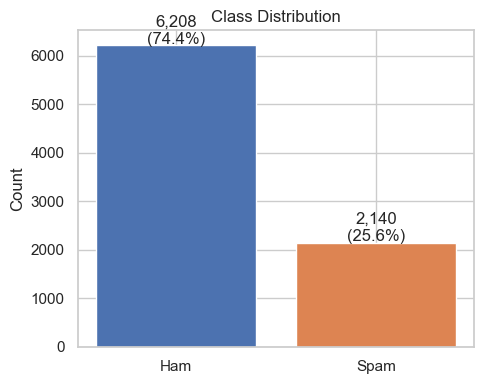

In [77]:
spam_count = original_training_data['spam'].sum()
ham_count  = len(original_training_data) - spam_count

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#4c72b0', '#dd8452'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(original_training_data):.1%})', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [78]:
first_ham  = original_training_data.loc[original_training_data['spam'] == 0, 'email'].iloc[0]
first_spam = original_training_data.loc[original_training_data['spam'] == 1, 'email'].iloc[0]

print('=== HAM EMAIL ===')
print(first_ham[:500])
print('\n' + '─' * 60)
print('=== SPAM EMAIL ===')
print(first_spam[:500])

=== HAM EMAIL ===
url: http://boingboing.net/#85534171
 date: not supplied
 
 arts and letters daily, a wonderful and dense blog, has folded up its tent due 
 to the bankruptcy of its parent company. a&l daily will be auctioned off by the 
 receivers. link[1] discuss[2] (_thanks, misha!_)
 
 [1] http://www.aldaily.com/
 [2] http://www.quicktopic.com/boing/h/zlfterjnd6jf
 
 


────────────────────────────────────────────────────────────
=== SPAM EMAIL ===
<html>
 <head>
 </head>
 <body>
 <font size=3d"4"><b> a man endowed with a 7-8" hammer is simply<br>
  better equipped than a man with a 5-6"hammer. <br>
 <br>would you rather have<br>more than enough to get the job done or fall =
 short. it's totally up<br>to you. our methods are guaranteed to increase y=
 our size by 1-3"<br> <a href=3d"http://209.163.187.47/cgi-bin/index.php?10=
 004">come in here and see how</a>
 </body>
 </html>
 
 
 



A few signals immediately distinguish spam from ham in these examples:

- **HTML markup** — spam uses `<html>` and styled formatting; ham is plain text
- **Suspicious URLs** — spam links point to obscure numerical IPs; ham links reference recognizable domains
- **Tone** — spam promotes products in a pushy way; ham discusses news or technical topics

### Train / Validation Split
10% of the labeled data is held out for validation with a fixed random seed for reproducibility.

In [79]:
from sklearn.model_selection import train_test_split

train, val = train_test_split(original_training_data, test_size=0.1, random_state=42)
train = train.reset_index(drop=True)
val   = val.reset_index(drop=True)

Y_train = train['spam'].values
Y_val   = val['spam'].values

print(f"Train: {len(train):,} emails  |  Val: {len(val):,} emails")
print(f"Train spam rate: {Y_train.mean():.1%}  |  Val spam rate: {Y_val.mean():.1%}")

Train: 7,513 emails  |  Val: 835 emails
Train spam rate: 25.5%  |  Val spam rate: 26.6%


## Text Preprocessing
Strip HTML, punctuation, digits, and stop words before featurization.

In [80]:
stop_words = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves',
    'you', 'your', 'yours', 'yourself', 'yourselves', 'he', 'him',
    'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its',
    'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what',
    'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am',
    'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has',
    'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the',
    'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of',
    'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to',
    'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under',
    'again', 'further', 'then', 'once', 'here', 'there', 'when',
    'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own',
    'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will',
    'just', 'don', 'should', 'now', 'nbsp'
}

def filter_data(text):
    """Strip HTML tags, non-alpha characters, digits, and stop words."""
    text = re.sub(r'<[^>]*>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

train['clean_email'] = train['email'].apply(filter_data)
val['clean_email']   = val['email'].apply(filter_data)

print("Sample cleaned email:")
print(train['clean_email'].iloc[0][:300])

Sample cleaned email:
playing past issues annoyed easy way make log stop growing dont mean truncate mean freeze following patch adds new button log window allows log switched onoff button says disable log enabled button disables enable log frozen button enables kre maintcl wed aug usrlocallibexmhmaintcl wed aug exmhlogcr


### Most Frequent Words in Spam vs. Ham

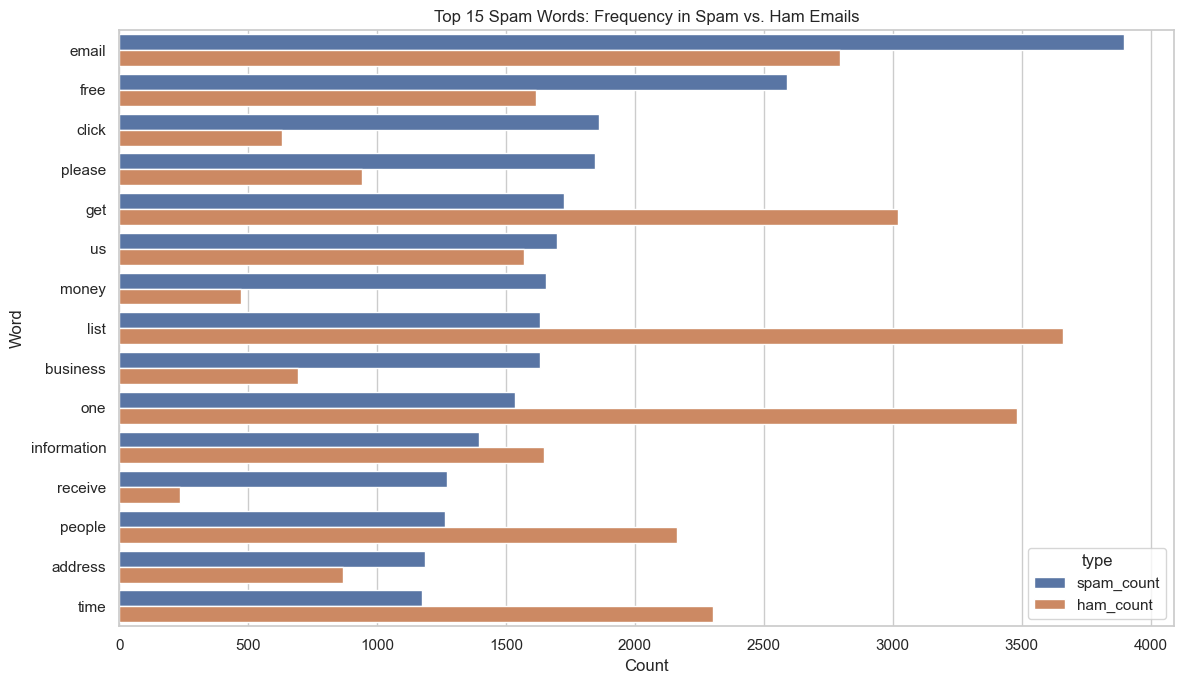

In [81]:
spam_word_counts = Counter(
    ' '.join(train.loc[train['spam'] == 1, 'clean_email']).split()
)
ham_word_counts = Counter(
    ' '.join(train.loc[train['spam'] == 0, 'clean_email']).split()
)

top_15_spam = dict(spam_word_counts.most_common(15))
words_df = pd.DataFrame({
    'word':       list(top_15_spam.keys()),
    'spam_count': list(top_15_spam.values()),
    'ham_count':  [ham_word_counts[w] for w in top_15_spam.keys()],
})
words_df = words_df.melt(id_vars='word', var_name='type', value_name='count')

plt.figure(figsize=(12, 7))
sns.barplot(data=words_df, x='count', y='word', hue='type')
plt.title('Top 15 Spam Words: Frequency in Spam vs. Ham Emails')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

## Feature Engineering

### Word Indicators
Use the **top 50 most frequent words in spam emails** from the training set as features for the baseline model. Each email is then encoded as a binary vector: 1 if the word is present, 0 otherwise.

In [82]:
def words_in_texts(words, texts):
    """Returns a binary (n_emails × n_words) indicator matrix."""
    indicator_array = np.zeros((len(texts), len(words)), dtype=int)
    for i, text in enumerate(texts):
        for j, word in enumerate(words):
            if word in text:
                indicator_array[i, j] = 1
    return indicator_array

# top 50 words in spam training emails
spam_ls = [word for word, _ in spam_word_counts.most_common(50)]

X_train_words = words_in_texts(spam_ls, train['clean_email'])
X_val_words   = words_in_texts(spam_ls, val['clean_email'])

print(f"feature matrix: {X_train_words.shape}  ({X_train_words.shape[1]} features per email)")

feature matrix: (7513, 50)  (50 features per email)


### TF-IDF + Engineered Features

TF-IDF to capture how much a word matters to a specific email, not just frequency. Combined with structural features that capture spam-typical patterns:

| Feature | Description |
|---|---|
| `unique_words` | Count of distinct words in the cleaned email |
| `digit_count` | Count of digit characters in the raw email |
| `html_present` | 1 if the email contains HTML markup |
| `url_count` | Number of URLs (`http`) in the email |
| `exclamation_count` | Number of `!` characters |
| `capital_ratio` | Fraction of alphabetic characters that are uppercase |
| `email_length` | Total character count of the email body |

In [83]:
def engineer_features(df):
    emails = df['email']
    clean  = df['clean_email']
    return pd.DataFrame({
        'unique_words':      clean.apply(lambda x: len(set(x.split()))),
        'digit_count':       emails.apply(lambda x: len(re.findall(r'\d', x))),
        'html_present':      emails.str.contains('<html', regex=False).astype(int),
        'url_count':         emails.str.count('http'),
        'exclamation_count': emails.str.count('!'),
        'capital_ratio':     emails.apply(
            lambda x: sum(c.isupper() for c in x) / max(len(x), 1)
        ),
        'email_length':      emails.str.len(),
    }).values

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(train['clean_email'])
X_val_tfidf   = tfidf.transform(val['clean_email'])

X_train_eng = engineer_features(train)
X_val_eng   = engineer_features(val)

X_train_combined = scipy.sparse.hstack([X_train_tfidf, scipy.sparse.csr_matrix(X_train_eng)])
X_val_combined   = scipy.sparse.hstack([X_val_tfidf,   scipy.sparse.csr_matrix(X_val_eng)])

print(f"TF-IDF features:     {X_train_tfidf.shape[1]}")
print(f"Engineered features: {X_train_eng.shape[1]}")
print(f"Combined shape:      {X_train_combined.shape}")

TF-IDF features:     5000
Engineered features: 7
Combined shape:      (7513, 5007)


## Modeling

### Logistic Regression on Word Indicators
Training on the top-50 word features as the baseline model.

In [85]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train_words, Y_train)

print(f"Training accuracy:   {baseline_model.score(X_train_words, Y_train):.4f}")
print(f"Validation accuracy: {baseline_model.score(X_val_words,   Y_val):.4f}")

Training accuracy:   0.9023
Validation accuracy: 0.9054


### Hyperparameter Tuning: Logistic Regression
Grid search over regularization strength (C) and penalty type (L1 vs L2) using 5-fold cross-validation, scored on F1 to balance precision and recall.

In [86]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],
}

lr_cv = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
)
lr_cv.fit(X_train_combined, Y_train)

best_C       = lr_cv.best_params_['C']
best_penalty = lr_cv.best_params_['penalty']

print(f"Best parameters:  C={best_C}, penalty='{best_penalty}'")
print(f"Best CV F1 score: {lr_cv.best_score_:.4f}")

Best parameters:  C=10, penalty='l1'
Best CV F1 score: 0.9711


### Naive Bayes

Multinomial Naive Bayes has a natural probabilistic fit for word count data, making it the standard text classification baseline alongside logistic regression.

In [87]:
from sklearn.naive_bayes import MultinomialNB

lr_model = LogisticRegression(
    C=best_C, penalty=best_penalty, solver='liblinear',
    max_iter=1000, random_state=42
)
lr_model.fit(X_train_combined, Y_train)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, Y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Evaluation
All metrics on the held-out validation set. Recall is prioritized — low recall means spam reaches the inbox.

In [88]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

def compute_metrics(model, X, y_true):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else None,
    }

In [89]:
results = {
    'Baseline LR (top-50 word indicators)': compute_metrics(baseline_model, X_val_words,    Y_val),
    'Logistic Regression (TF-IDF)':         compute_metrics(lr_model,       X_val_combined, Y_val),
    'Naive Bayes (TF-IDF)':                 compute_metrics(nb_model,       X_val_tfidf,    Y_val),
}

results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Baseline LR (top-50 word indicators),0.9054,0.8994,0.7252,0.8030,0.9389
Logistic Regression (TF-IDF),0.9928,1.0000,0.9730,0.9863,0.9998
Naive Bayes (TF-IDF),0.9749,0.9674,0.9369,0.9519,0.9968


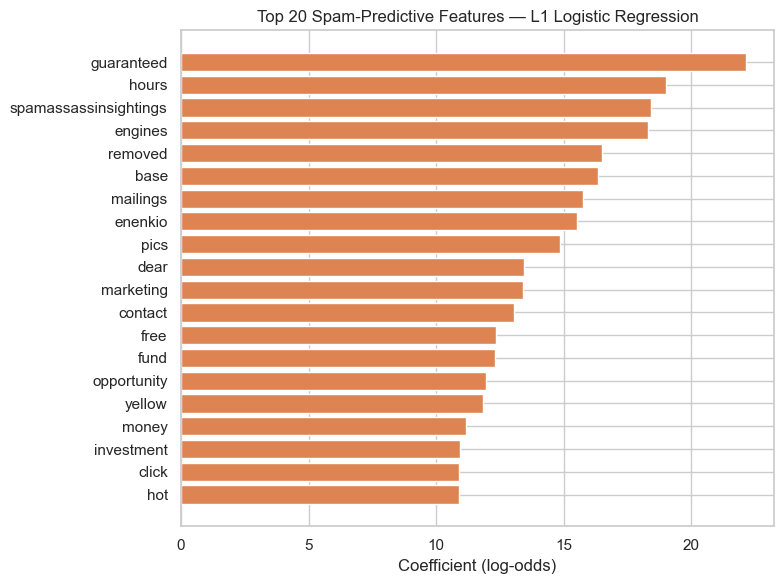

In [90]:
feature_names = list(tfidf.get_feature_names_out()) + [
    'unique_words', 'digit_count', 'html_present',
    'url_count', 'exclamation_count', 'capital_ratio', 'email_length'
]

coef = lr_model.coef_[0]
top_idx = np.argsort(coef)[-20:][::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([feature_names[i] for i in top_idx[::-1]], coef[top_idx[::-1]], color='#dd8452')
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 20 Spam-Predictive Features — L1 Logistic Regression')
plt.tight_layout()
plt.show()

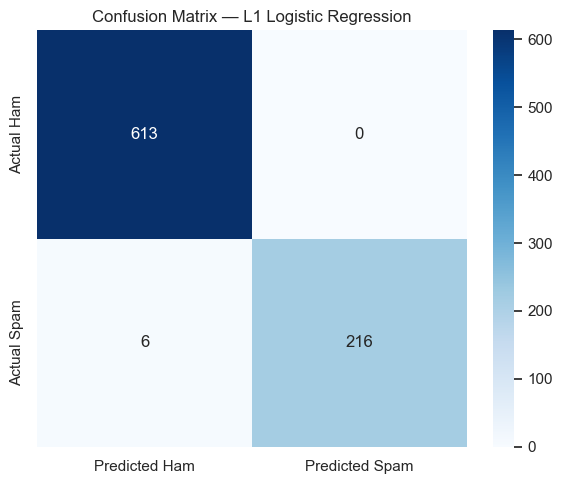

In [91]:
from sklearn.metrics import confusion_matrix

y_pred_best = lr_model.predict(X_val_combined)
cm = confusion_matrix(Y_val, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
ax.set_title('Confusion Matrix — L1 Logistic Regression')
plt.tight_layout()
plt.show()

Zero false positives / no legitimate email flagged as spam. Six false negatives / spam emails missed, reflected in the 97.3% recall.

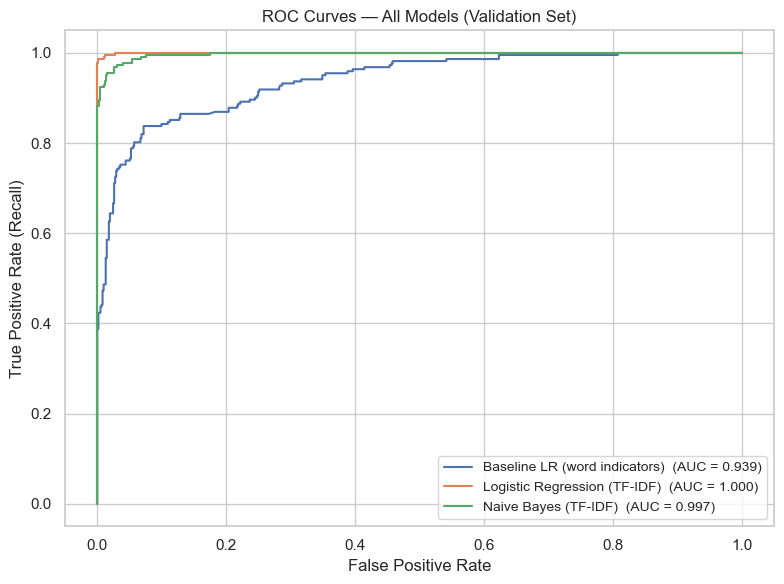

In [92]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

roc_models = [
    ('Baseline LR (word indicators)', baseline_model, X_val_words),
    ('Logistic Regression (TF-IDF)',  lr_model,       X_val_combined),
    ('Naive Bayes (TF-IDF)',          nb_model,       X_val_tfidf),
]

for name, model, X_val_data in roc_models:
    y_prob = model.predict_proba(X_val_data)[:, 1]
    fpr, tpr, _ = roc_curve(Y_val, y_prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc(fpr, tpr):.3f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — All Models (Validation Set)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## Conclusions

Starting from a simple binary word indicator baseline, progressive improvements to feature representation drove the largest performance gains. Moving to TF-IDF over a 5,000-word vocabulary — combined with structural email features and L1-regularized logistic regression tuned via 5-fold cross-validation — pushed accuracy to 99.3% and recall to 97.3% on the held-out validation set, correctly catching the vast majority of spam while generating virtually no false positives.

The main takeaway is that feature quality mattered more than model complexity: Naive Bayes on TF-IDF features far outperformed the baseline logistic regression, and the tuned LR model outperformed all others. The SpamAssassin corpus dates to 2004 and modern spam has evolved significantly toward phishing and social engineering, so generalization to current email would require retraining on contemporary data — or replacing TF-IDF with contextual embeddings like BERT.